In [23]:
import pandas as pd
import numpy as np

df = pd.read_csv('/kaggle/input/datasets/mahirprojects/marketing-results/marketing_campaign_dataset.csv')

df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


In [28]:
df["Acquisition_Cost"] = df["Acquisition_Cost"].astype(str).str.replace(r'[\$,]', '', regex=True)
df["Acquisition_Cost"] = pd.to_numeric(df["Acquisition_Cost"], errors="coerce")
df["Clicks"] = pd.to_numeric(df["Clicks"], errors="coerce")
df["Impressions"] = pd.to_numeric(df["Impressions"], errors="coerce")
df["ROI"] = pd.to_numeric(df["ROI"], errors="coerce")


In [29]:
df["CTR"] = df["Clicks"] / df["Impressions"]
df["Cost_per_Click"] = df["Acquisition_Cost"] / df["Clicks"]
df["Month"] = df["Date"].dt.month

In [30]:
features = df[[
    "Campaign_Type",
    "Target_Audience",
    "Channel_Used",
    "Duration",
    "Clicks",
    "Impressions",
    "Engagement_Score",
    "Customer_Segment",
    "CTR",
    "Cost_per_Click",
    "Month"
]]

target = df["ROI"]

In [31]:
features_encoded = pd.get_dummies(features, drop_first=True)

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features_encoded, target, test_size=0.2, random_state=42
)

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: -0.0002363590918685876
RMSE: 1.7356392250828947


In [34]:
coefficients = pd.DataFrame({
    "Feature": features_encoded.columns,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

print(coefficients.head(10))
print(coefficients.tail(10))

                                 Feature  Coefficient
14                 Channel_Used_Facebook     0.028942
11             Target_Audience_Men 25-34     0.018676
3                                    CTR     0.017824
17                  Channel_Used_Website     0.017079
19                      Duration_30 days     0.014725
7               Campaign_Type_Influencer     0.012349
23    Customer_Segment_Health & Wellness     0.010395
15               Channel_Used_Google Ads     0.007742
24  Customer_Segment_Outdoor Adventurers     0.007735
21                      Duration_60 days     0.007153
                        Feature  Coefficient
0                        Clicks     0.000016
1                   Impressions     0.000004
2              Engagement_Score    -0.000495
22     Customer_Segment_Foodies    -0.001234
16       Channel_Used_Instagram    -0.003836
12  Target_Audience_Women 25-34    -0.004259
6           Campaign_Type_Email    -0.005627
18         Channel_Used_YouTube    -0.007035
9

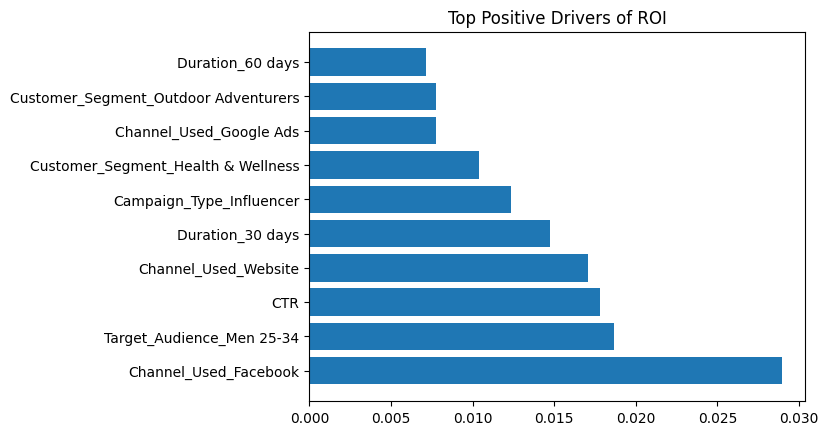

In [35]:
import matplotlib.pyplot as plt

top_features = coefficients.head(10)

plt.figure()
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.title("Top Positive Drivers of ROI")
plt.show()